#### Building a linear regression model

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

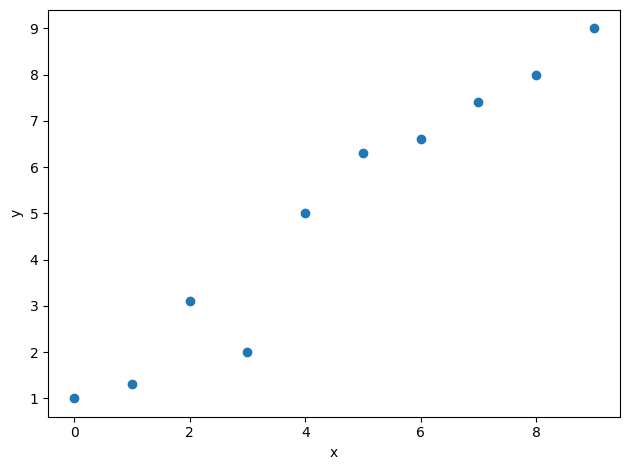

In [2]:
# create toy dataset
X_train = np.arange(10, dtype='float32').reshape(-1, 1)
y_train = np.array([1.0, 1.3, 3.1, 2.0, 5.0, 6.3, 6.6, 7.4, 8.0, 9.0], dtype='float32')

plt.scatter(X_train, y_train)
plt.xlabel("x")
plt.ylabel("y")
plt.tight_layout()
plt.show()

In [3]:
# create Dataset and DataLoader
from torch.utils.data import TensorDataset, DataLoader, Dataset

X_train_norm = (X_train - np.mean(X_train)) / np.std(X_train)
X_train_norm = torch.from_numpy(X_train_norm).float()

y_train = torch.from_numpy(y_train).float()

train_ds = TensorDataset(X_train_norm, y_train)
batch_size = 1
train_data_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

In [4]:
torch.manual_seed(1)

# initialize w and b
weight = torch.randn(1, requires_grad=True)
bias = torch.zeros(1)
bias.requires_grad_()
print(weight, bias)

tensor([0.6614], requires_grad=True) tensor([0.], requires_grad=True)


In [5]:
# create model
def model(x):
    return x @ weight + bias

# create loss fn
def loss_fn(pred, target):
    return ((pred-target)**2).mean()

In [6]:
lr = 1e-3
num_epochs = 100
log_epochs = 10

for epoch in range(num_epochs):
    for x_batch, y_batch in train_data_loader:
        y_preds = model(x_batch)
        loss = loss_fn(y_preds, y_batch)
        loss.backward()
    with torch.no_grad():
        weight -= weight.grad * lr
        bias -= bias.grad * lr
        weight.grad.zero_()
        bias.grad.zero_()
    if epoch % log_epochs==0:
        print(f"Epoch {epoch}: Loss {loss.item():.4f}")

Epoch 0: Loss 46.5720
Epoch 10: Loss 27.1502
Epoch 20: Loss 1.6446
Epoch 30: Loss 14.4571
Epoch 40: Loss 11.7827
Epoch 50: Loss 6.4122
Epoch 60: Loss 0.6339
Epoch 70: Loss 3.1562
Epoch 80: Loss 2.0100
Epoch 90: Loss 0.3107


In [7]:
y_preds = model(X_train_norm)
print(y_preds)

tensor([0.4950, 1.3430, 2.1909, 3.0389, 3.8869, 4.7349, 5.5828, 6.4308, 7.2788,
        8.1268], grad_fn=<AddBackward0>)


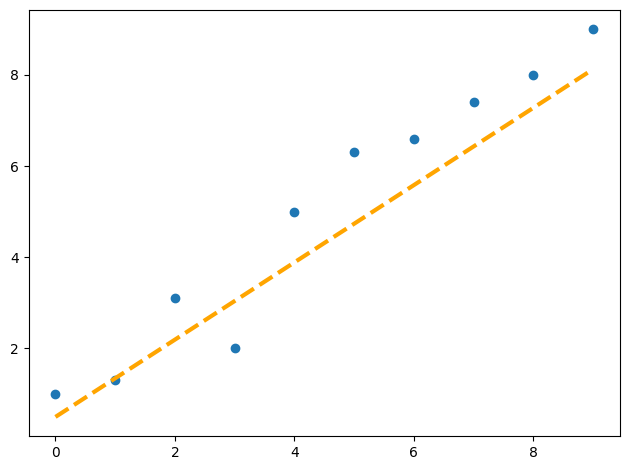

In [8]:
plt.scatter(X_train, y_train)
plt.plot(X_train, y_preds.detach().numpy(), color="orange", linestyle="--", lw=3)
plt.tight_layout()
plt.show()

#### Using torch.nn and torch.optim

In [9]:
import torch.nn as nn
loss_fn = nn.MSELoss(reduction="mean")
input_size = 1
output_size = 1
lr = 1e-3
model = nn.Linear(input_size, output_size)
optimizer = torch.optim.SGD(model.parameters(), lr=lr)

In [10]:
num_epochs = 200
for epoch in range(num_epochs):
    for x_batch, y_batch in train_data_loader:
        pred = model(x_batch)
        loss = loss_fn(pred, y_batch)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: Loss {loss.item()}")

/home/vinhn/bigdrive/course-repository/general-env/lib/python3.12/site-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([1, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 0: Loss 3.6514854431152344
Epoch 10: Loss 10.061869621276855
Epoch 20: Loss 1.2880659103393555
Epoch 30: Loss 5.2254743576049805
Epoch 40: Loss 15.171463012695312
Epoch 50: Loss 9.992573738098145
Epoch 60: Loss 0.09828370064496994
Epoch 70: Loss 5.766489028930664
Epoch 80: Loss 0.2832653820514679
Epoch 90: Loss 1.9978631734848022
Epoch 100: Loss 1.4699807167053223
Epoch 110: Loss 2.4078798294067383
Epoch 120: Loss 2.0339877605438232
Epoch 130: Loss 0.13553178310394287
Epoch 140: Loss 0.32975783944129944
Epoch 150: Loss 0.4225035309791565
Epoch 160: Loss 0.04200151190161705
Epoch 170: Loss 0.45815926790237427
Epoch 180: Loss 0.09695135802030563
Epoch 190: Loss 0.31440767645835876


#### Building a multilayer perceptrong for classifying flowers in the Iris dataset

In [11]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

iris = load_iris()
X = iris.data
y = iris.target

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, shuffle=True,
                                                     random_state=1, test_size=0.3)

In [13]:
# scale
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)

In [14]:
# convert to tensor
X_train_norm_tensor = torch.as_tensor(X_train_norm, dtype=torch.float)
X_test_norm_tensor = torch.as_tensor(X_test_norm, dtype=torch.float)
y_train_tensor = torch.as_tensor(y_train, dtype=torch.long)
y_test_tensor = torch.as_tensor(y_test, dtype=torch.long)

In [28]:
# create Dataset and DataLoader
train_ds = TensorDataset(X_train_norm_tensor, y_train_tensor)

torch.manual_seed(2)
batch_size = 4
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)

In [29]:
# create model
class Model(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.layer1 = nn.Linear(input_size, hidden_size)
        self.layer2 = nn.Linear(hidden_size, output_size)
    def forward(self, x):
        x = self.layer1(x)
        x = nn.Sigmoid()(x)
        x = self.layer2(x)
        return x
    
input_size = 4
hidden_size = 16
output_size = 3

model = Model(input_size, hidden_size, output_size)

In [30]:
# define hyperparams for loss and backpropagation
learning_rate = 1e-3
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params=model.parameters(), lr=learning_rate)

In [31]:
num_epochs = 100
loss_hist = []
accuracy_hist = []

for epoch in range(num_epochs):
    epoch_loss = 0
    epoch_accuracy = 0
    for x_batch, y_batch in train_dl:
        pred = model.forward(x_batch)

        loss = loss_fn(pred, y_batch.to(torch.long))
        loss.backward()

        optimizer.step()
        optimizer.zero_grad()

        epoch_loss += loss.item() * y_batch.size(0)
        is_correct = (torch.argmax(pred, dim=1)==y_batch).float().sum()
        epoch_accuracy += is_correct

    loss_hist.append(epoch_loss/len(train_dl.dataset))
    accuracy_hist.append(epoch_accuracy/len(train_dl.dataset))


In [34]:
print(model.forward(x_batch))
print(torch.argmax(model.forward(x_batch), dim=1))

tensor([[ 4.4261,  0.4352, -6.6221],
        [-5.3182,  0.2715,  1.9941],
        [-2.7281,  0.8951, -0.8434],
        [-5.1446,  0.4430,  1.6999]], grad_fn=<AddmmBackward0>)
tensor([0, 2, 1, 2])


In [33]:
y_batch

tensor([0, 2, 1, 2])

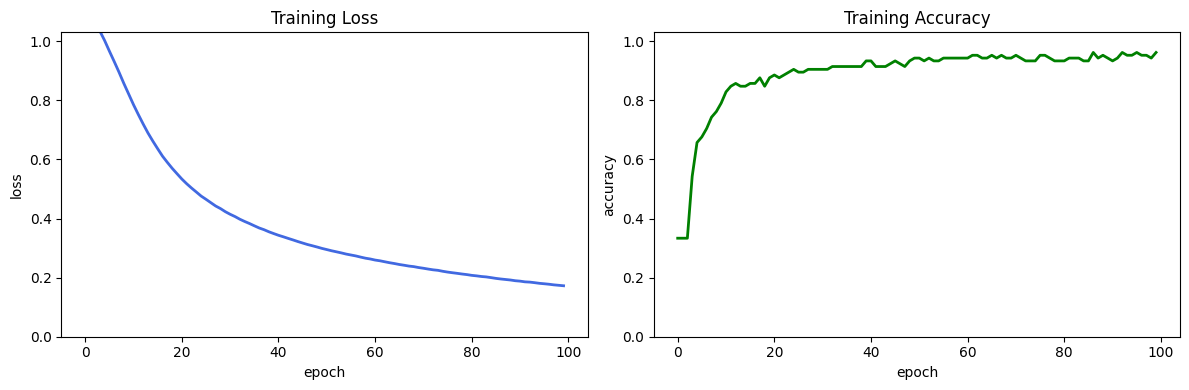

In [19]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(loss_hist, lw=2, color="royalblue")
ax[0].set_title("Training Loss")
ax[0].set_xlabel("epoch")
ax[0].set_ylabel("loss")
ax[0].set_ylim([0.0, 1.03])


ax[1].plot(accuracy_hist, lw=2, color="g")
ax[1].set_title("Training Accuracy")
ax[1].set_xlabel("epoch")
ax[1].set_ylabel("accuracy")
ax[1].set_ylim([0.0, 1.03])

plt.tight_layout()
plt.show()

In [20]:
# Evaluate the trained model on the test dataset
pred_test = model.forward(X_test_norm_tensor)
is_correct = (torch.argmax(pred_test, dim=1) == y_test_tensor).float().mean()
print(f"Test accuracy: {is_correct}")

Test accuracy: 0.9555555582046509


In [21]:
# save the model
path = '../model/iris_classifier.pt'
torch.save(model, path)

In [22]:
# load the model
load_model = torch.load(path, weights_only=False)
load_model.eval()

Model(
  (layer1): Linear(in_features=4, out_features=16, bias=True)
  (layer2): Linear(in_features=16, out_features=3, bias=True)
)

In [23]:
# Evaluate the loaded model on the test dataset
pred_test_new = load_model.forward(X_test_norm_tensor)
is_correct_new = (torch.argmax(pred_test_new, dim=1) == y_test_tensor).float().mean()
print(f"Test accuracy: {is_correct_new}")

Test accuracy: 0.9555555582046509


In [24]:
# save model state dict only
path = '../model/iris_classifier_state.pt'
torch.save(model.state_dict(), path)

In [25]:
# load new model:
model_new = Model(input_size, hidden_size, output_size)
model_new.load_state_dict(torch.load(path))

<All keys matched successfully>